<a href="https://colab.research.google.com/github/BJut7021/TH_DeepLearning/blob/main/THDL_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2.1. Nạp thư viện

In [1]:
from pandas import read_csv
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import math
import matplotlib.pyplot as plt

2.2. Tạo hàm định nghĩa mô hình RNN

In [2]:
def create_RNN(hideden_units, dense_units, input_shape, activation):
  model = Sequential()
  model.add(SimpleRNN(hideden_units, input_shape=input_shape, activation=activation[0]))
  model.add(Dense(dense_units, activation=activation[1]))
  model.compile( optimizer='adam',loss='mean_squared_error')
  return model

demo_RNN = create_RNN(2, 1, (3, 1), ('linear', 'linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2.3. Xem các tham số sinh bởi RNN

In [3]:
wx = demo_RNN.get_weights()[0]
wh = demo_RNN.get_weights()[1]
bh = demo_RNN.get_weights()[2]
wy = demo_RNN.get_weights()[3]
by = demo_RNN.get_weights()[4]

print('wx = ', wx)
print('wh = ', wh)
print('bh = ', bh)
print('wy = ', wy)
print('by = ', by)


wx =  [[ 0.43272305 -0.3191265 ]]
wh =  [[-0.23760855  0.971361  ]
 [ 0.971361    0.23760855]]
bh =  [0. 0.]
wy =  [[ 0.34041202]
 [-1.277359  ]]
by =  [0.]



2.4. Tính vector hidden cho tầng recurrent

In [4]:
x = np.array([1,2,3])

x_input = np.reshape(x, (1, 3, 1))
y_predict_model = demo_RNN.predict(x_input)

m = 2
h0 = np.zeros(m)
h1 = np.dot(x[0], wx) + bh + h0
h2 = np.dot(x[1], wx) + bh + np.dot(h1, wh)
h3 = np.dot(x[2], wx) + bh + np.dot(h2, wh)

o3 = np.dot(h3, wy) + by

print('h1 = ', h1)
print('h2 = ', h2)
print('h3 = ', h3)
print('y_predict_model = ', y_predict_model)

print('Prediction of model:', y_predict_model)
print('Prediction of hand calculation:', o3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
h1 =  [[ 0.43272305 -0.31912649]]
h2 =  [[ 0.45264038 -0.29374987]]
h3 =  [[ 0.90528075 -0.58749974]]
y_predict_model =  [[1.0586165]]
Prediction of model: [[1.0586165]]
Prediction of hand calculation: [[1.05861654]]


3. ÁP DỤNG RNN CHO ỨNG DỤNG THỰC TẾ

3.1. Đọc dữ liệu

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

def get_train_test(url, split_percent=0.8):
  df = pd.read_csv(url, usecols=[1], engine='python')
  data = np.array(df.values.astype('float32'))
  scaler = MinMaxScaler(feature_range=(0, 1))
  data = scaler.fit_transform(data).flatten()

  n = len(data)

  split = int(n * split_percent)

  train = data[range(split)]
  test = data[split:]

  return train, test, scaler

sunspots_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-sunspots.csv'
train_data, test_data, scaler = get_train_test(sunspots_url)


3.2. Chuẩn bị dữ liệu cho RNN

In [6]:
def get_XY(dat, time_steps):

  y_ind = np.arange(time_steps, len(dat), time_steps)
  Y = dat[y_ind]

  rows_x = len(Y)
  X= dat[range(time_steps*rows_x)]
  X = np.reshape(X, (rows_x, time_steps, 1))
  return X, Y

time_steps = 12
trainX, trainY = get_XY(train_data, time_steps)
testX, testY = get_XY(test_data, time_steps)

3.3. Tạo RNN model và huấn luyện

In [7]:
model = create_RNN(hideden_units=3, dense_units=1, input_shape=(time_steps, 1), activation=['tanh', 'tanh'])
model.fit = model.fit(trainX, trainY, epochs=20, verbose=1)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0317
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0282 
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0259 
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0242 
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0228 
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0216 
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0206 
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0196 
Epoch 9/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0187 
Epoch 10/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0179 
Epoch 11/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0171 
Epoch 12/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0165 
Epoch 13/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0159 
Epoch 14/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154
Epoch 15/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0148 
Epoch 16/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/st

3.4. Hàm tính hiệu quả model


In [8]:
def print_error(trainY, textY, train_predict, test_predict):

  train_rmse = math.sqrt(mean_squared_error(trainY, train_predict))
  test_rmse = math.sqrt(mean_squared_error(textY, test_predict))

  print('Train RMSE: %.3f' % train_rmse)
  print('Test RMSE: %.3f' % test_rmse)

train_predict = model.predict(trainX)
test_predict = model.predict(testX)

print_error(trainY, testY, train_predict, test_predict)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Train RMSE: 0.111
Test RMSE: 0.146


3.5. Đánh giá kết quả

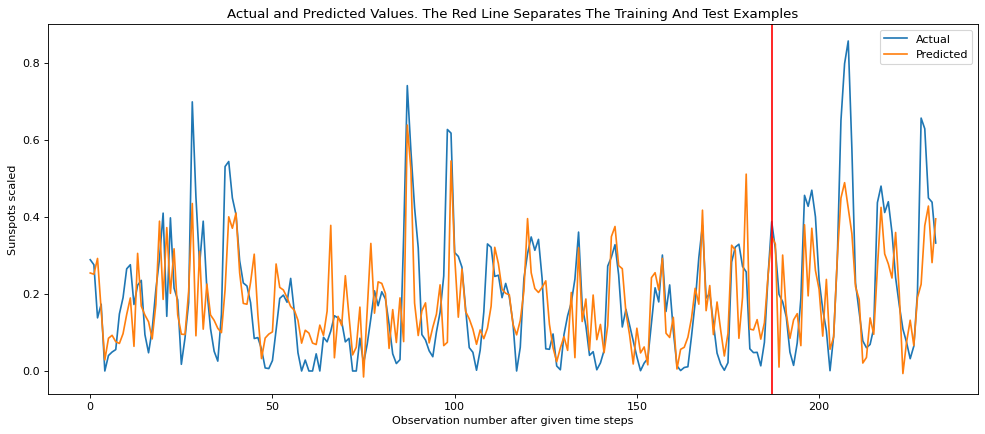

In [9]:
def plot_result(trainY, testY,  train_predict, test_predict):

  actual = np.append(trainY, testY)
  predictions = np.append(train_predict, test_predict)
  rows = len(actual)

  plt.figure(figsize=(15, 6), dpi=80)
  plt.plot(range(rows),actual)
  plt.plot(range(rows), predictions)

  plt.axvline(x=len(trainY), color='r')
  plt.legend(['Actual', 'Predicted'])
  plt.xlabel('Observation number after given time steps')
  plt.ylabel('Sunspots scaled')
  plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
  plt.show()

plot_result(trainY, testY,train_predict,  test_predict)

Bài tập

In [32]:
import pandas as pd
import numpy as np

# Đặt seed để kết quả mô phỏng luôn cố định trong các lần chạy
np.random.seed(42)

# THAY ĐỔI 1: Giảm số bước thời gian xuống còn 200 dòng dữ liệu
so_dong = 200
thoi_gian = np.arange(so_dong)

# THAY ĐỔI 2: Tăng hệ số xu hướng để giá nhà tăng rõ ràng hơn trong chuỗi ngắn
xu_huong = thoi_gian * 600

# THAY ĐỔI 3: Thu hẹp mẫu số chu kỳ (chia 3 thay vì 12) để sóng chu kỳ kịp trồi sụt trong 200 dòng
chu_ky = np.sin(thoi_gian / 3) * 40000

# THAY ĐỔI 4: Điều chỉnh độ lệch chuẩn của nhiễu (25,000) phù hợp biên độ chuỗi 200 dòng
nhieu_thi_truong = np.random.normal(0, 25000, so_dong)

# Giả lập giá nhà: Giá nền + Xu hướng tăng dần + Chu kỳ hình sin + Nhiễu ngẫu nhiên
gia_nha = 500000 + xu_huong + chu_ky + nhieu_thi_truong

# THAY ĐỔI 5: Giảm số điểm đột biến xuống (4 điểm) và giới hạn khoảng chọn chỉ số (index) trong phạm vi 200 dòng
for _ in range(4):
    idx = np.random.randint(20, 180)
    gia_nha[idx] += np.random.choice([120000, -100000])

# Tạo DataFrame với tên cột 'price' đúng như code RNN yêu cầu
df = pd.DataFrame({'price': gia_nha})

# Xuất ra file CSV
df.to_csv('raw_sales.csv', index=False)

print("Đã tạo thành công file 'raw_sales.csv' giả lập!")
print("Số dòng dữ liệu:", len(df))
print(df.head())

Đã tạo thành công file 'raw_sales.csv' giả lập!
Số dòng dữ liệu: 200
           price
0  512417.853825
1  510231.180343
2  542127.005575
3  573534.585803
4  535423.681686


In [33]:
#bài tập 1
# Đọc dữ liệu chuỗi thời gian từ cột 'price'
dataframe = read_csv('raw_sales.csv', usecols=['price'])
dataset = dataframe.values
dataset = dataset.astype('float32') # Chuyển đổi định dạng dữ liệu sang float32 phù hợp với mô hình Keras

Chuẩn hóa dữ liệu về khoảng [0, 1]

In [34]:
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

Phân chia tập dữ liệu thành Train và Test

In [35]:
train_size = int(len(dataset) * 0.70)
test_size = len(dataset) - train_size
train, test = dataset[0:train_size,:], dataset[train_size:len(dataset),:]

Xây dựng hàm tạo cấu trúc dữ liệu dạng cửa sổ trượt

In [36]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# Khởi tạo tham số look_back (Số bước thời gian quá khứ dùng để dự báo bước kế tiếp)
look_back = 3  # Bạn có thể thử nghiệm thay đổi giá trị này để tối ưu mô hình
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

Định hình lại cấu trúc ma trận đầu vào (Reshape 3D)

In [37]:
trainX = np.reshape(trainX, (trainX.shape[0], trainX.shape[1], 1))
testX = np.reshape(testX, (testX.shape[0], testX.shape[1], 1))

Xây dựng cấu trúc mạng mạng SimpleRNN và Huấn luyện

In [38]:
# Tạo mô hình học sâu tuần tự
model = Sequential()

# Thêm lớp SimpleRNN với 4 nút ẩn, cấu hình kích thước đầu vào đầu tensor là (look_back, 1)
model.add(SimpleRNN(4, input_shape=(look_back, 1)))

# Thêm lớp Dense (tuyến tính thông thường) đưa về 1 cổng ra dự báo giá duy nhất
model.add(Dense(1))

# Biên dịch mô hình với hàm mất mát MSE và bộ tối ưu hóa Adam
model.compile(loss='mean_squared_error', optimizer='adam')

# Thực hiện quá trình huấn luyện mạng dữ liệu
model.fit(trainX, trainY, epochs=30, batch_size=32, verbose=1)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0276
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0210 
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0164 
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0140 
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0130 
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0125 
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0125 
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0125 
Epoch 9/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0123 
Epoch 10/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0121 
Epoch 11/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0120 
Epoch 12/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0118 
Epoch 13/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0117 
Epoch 14/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0116 
Epoch 15/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0115 
Epoch 16/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/st

Thực hiện dự báo và trực quan hóa kết quả

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


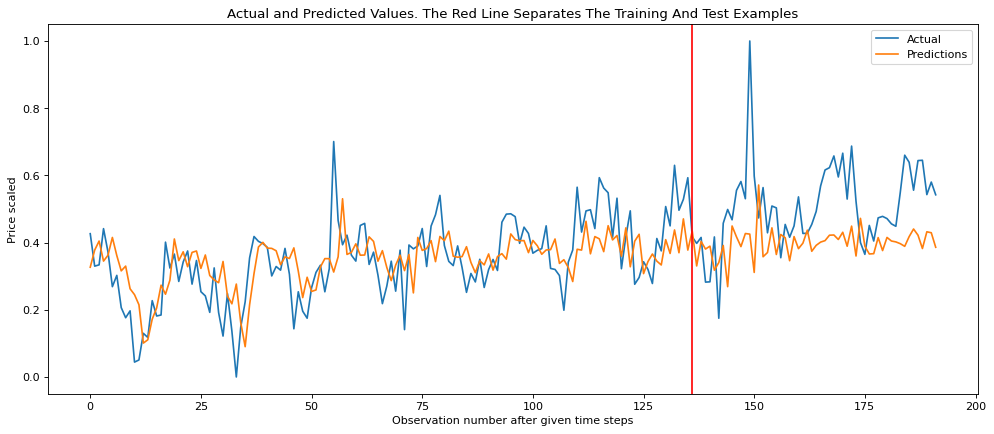

In [39]:
# Thực hiện dự báo mô hình
train_predict = model.predict(trainX)
test_predict = model.predict(testX)

# Khai báo hàm vẽ biểu đồ hiển thị kết quả chính xác
def plot_result(trainY, testY, train_predict, test_predict):
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual)
    plt.plot(range(rows), predictions)
    plt.axvline(x=len(trainY), color='r') # Vạch kẻ đỏ đứng phân tách phân vùng Train và Test
    plt.legend(['Actual', 'Predictions'])
    plt.xlabel('Observation number after given time steps')
    plt.ylabel('Price scaled')
    plt.title('Actual and Predicted Values. The Red Line Separates The Training And Test Examples')
    plt.show()

# Gọi hàm hiển thị đồ thị trên giao diện notebook của bạn
plot_result(trainY, testY, train_predict, test_predict)

In [40]:
# NGHỊCH ĐẢO CHUẨN HÓA VỀ GIÁ TRỊ THỰC THẾ
# Đưa kết quả dự báo và dữ liệu thực tế từ khoảng [0, 1] về lại giá tiền gốc
train_predict_actual = scaler.inverse_transform(train_predict)
trainY_actual = scaler.inverse_transform([trainY])

test_predict_actual = scaler.inverse_transform(test_predict)
testY_actual = scaler.inverse_transform([testY])

# TÍNH TOÁN ĐỘ ĐO SAI SỐ (RMSE)
# Tính toán sai số RMSE trên tập Train và tập Test
train_score = math.sqrt(mean_squared_error(trainY_actual[0], train_predict_actual[:,0]))
print(f'Sai số Tập Train (RMSE): {train_score:,.2f} VND')

test_score = math.sqrt(mean_squared_error(testY_actual[0], test_predict_actual[:,0]))
print(f'Sai số Tập Test (RMSE): {test_score:,.2f} VND')

Sai số Tập Train (RMSE): 39,476.14 VND
Sai số Tập Test (RMSE): 63,826.95 VND
